In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

PICKLE_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles'

# Stimulus-type colours
STIM_COLS = {
    'constant': '#2E7D32',   # dark green
    'ramp':     '#9933CC',   # purple
    'pink':     '#FF44CC',   # hot pink
}
STIM_ORDER  = ['constant', 'ramp', 'pink']
STIM_LABELS = {'constant': 'Constant', 'ramp': 'Ramp', 'pink': 'Pink noise'}

# Cell labels (from CRCNS PVC-6 data description)
CELL_LABELS = {
    1: 'Cell 1 (SST+)',      # 153098.04.02 — Somatostatin-positive
    2: 'Cell 2 (unmarked)',  # 151145.04    — Unmarked
}

FS_TITLE = 11
FS_LABEL = 10
FS_TICK  = 9
FS_ANNOT = 8
import os


In [2]:
# ── Run-control flags ─────────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles
PICKLE_DIR  = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles"


In [3]:
# ── Load pickles and build per-sweep summary ───────────────────────────────────
fs = 200000

cells = {}
for cnum, suffix in [(1, ''), (2, '2')]:
    with open(f'{PICKLE_DIR}/df_stim_features{suffix}.pkl', 'rb') as f:
        df = pickle.load(f)
    with open(f'{PICKLE_DIR}/all_data{suffix}.pkl', 'rb') as f:
        all_data = pickle.load(f)

    sweep_dur = {sweep: len(all_data[int(sweep)]) / fs
                 for sweep in df['sweep'].unique()}

    per_sweep = (df.groupby(['sweep', 'stim_type'])['spike_num']
                   .count()
                   .reset_index()
                   .rename(columns={'spike_num': 'n_spikes'}))
    per_sweep['duration_s'] = per_sweep['sweep'].map(sweep_dur)
    per_sweep['fr_hz']      = per_sweep['n_spikes'] / per_sweep['duration_s']
    per_sweep['cell']       = f'Cell {cnum}'

    pink_variants = (df[df['stim_type'] == 'pink']['pink_type'].nunique()
                     if 'pink_type' in df.columns else np.nan)

    cells[cnum] = dict(df=df, per_sweep=per_sweep, pink_variants=pink_variants)

    # Print quick summary
    print(f'\n=== Cell {cnum} ===')
    print(f'  Total spikes : {len(df)}')
    print(f'  Spikes / stim type:')
    print(df['stim_type'].value_counts().to_string())
    print(f'  Sweeps / stim type:')
    print(df.groupby('stim_type')['sweep'].nunique().to_string())
    print(f'  Pink noise variants: {pink_variants}')


=== Cell 1 ===
  Total spikes : 820
  Spikes / stim type:
pink        418
constant    233
ramp        169
  Sweeps / stim type:
stim_type
constant    20
pink        27
ramp         5
  Pink noise variants: 10

=== Cell 2 ===
  Total spikes : 380
  Spikes / stim type:
pink        296
constant     82
ramp          2
  Sweeps / stim type:
stim_type
constant    16
pink        26
ramp         1
  Pink noise variants: 9


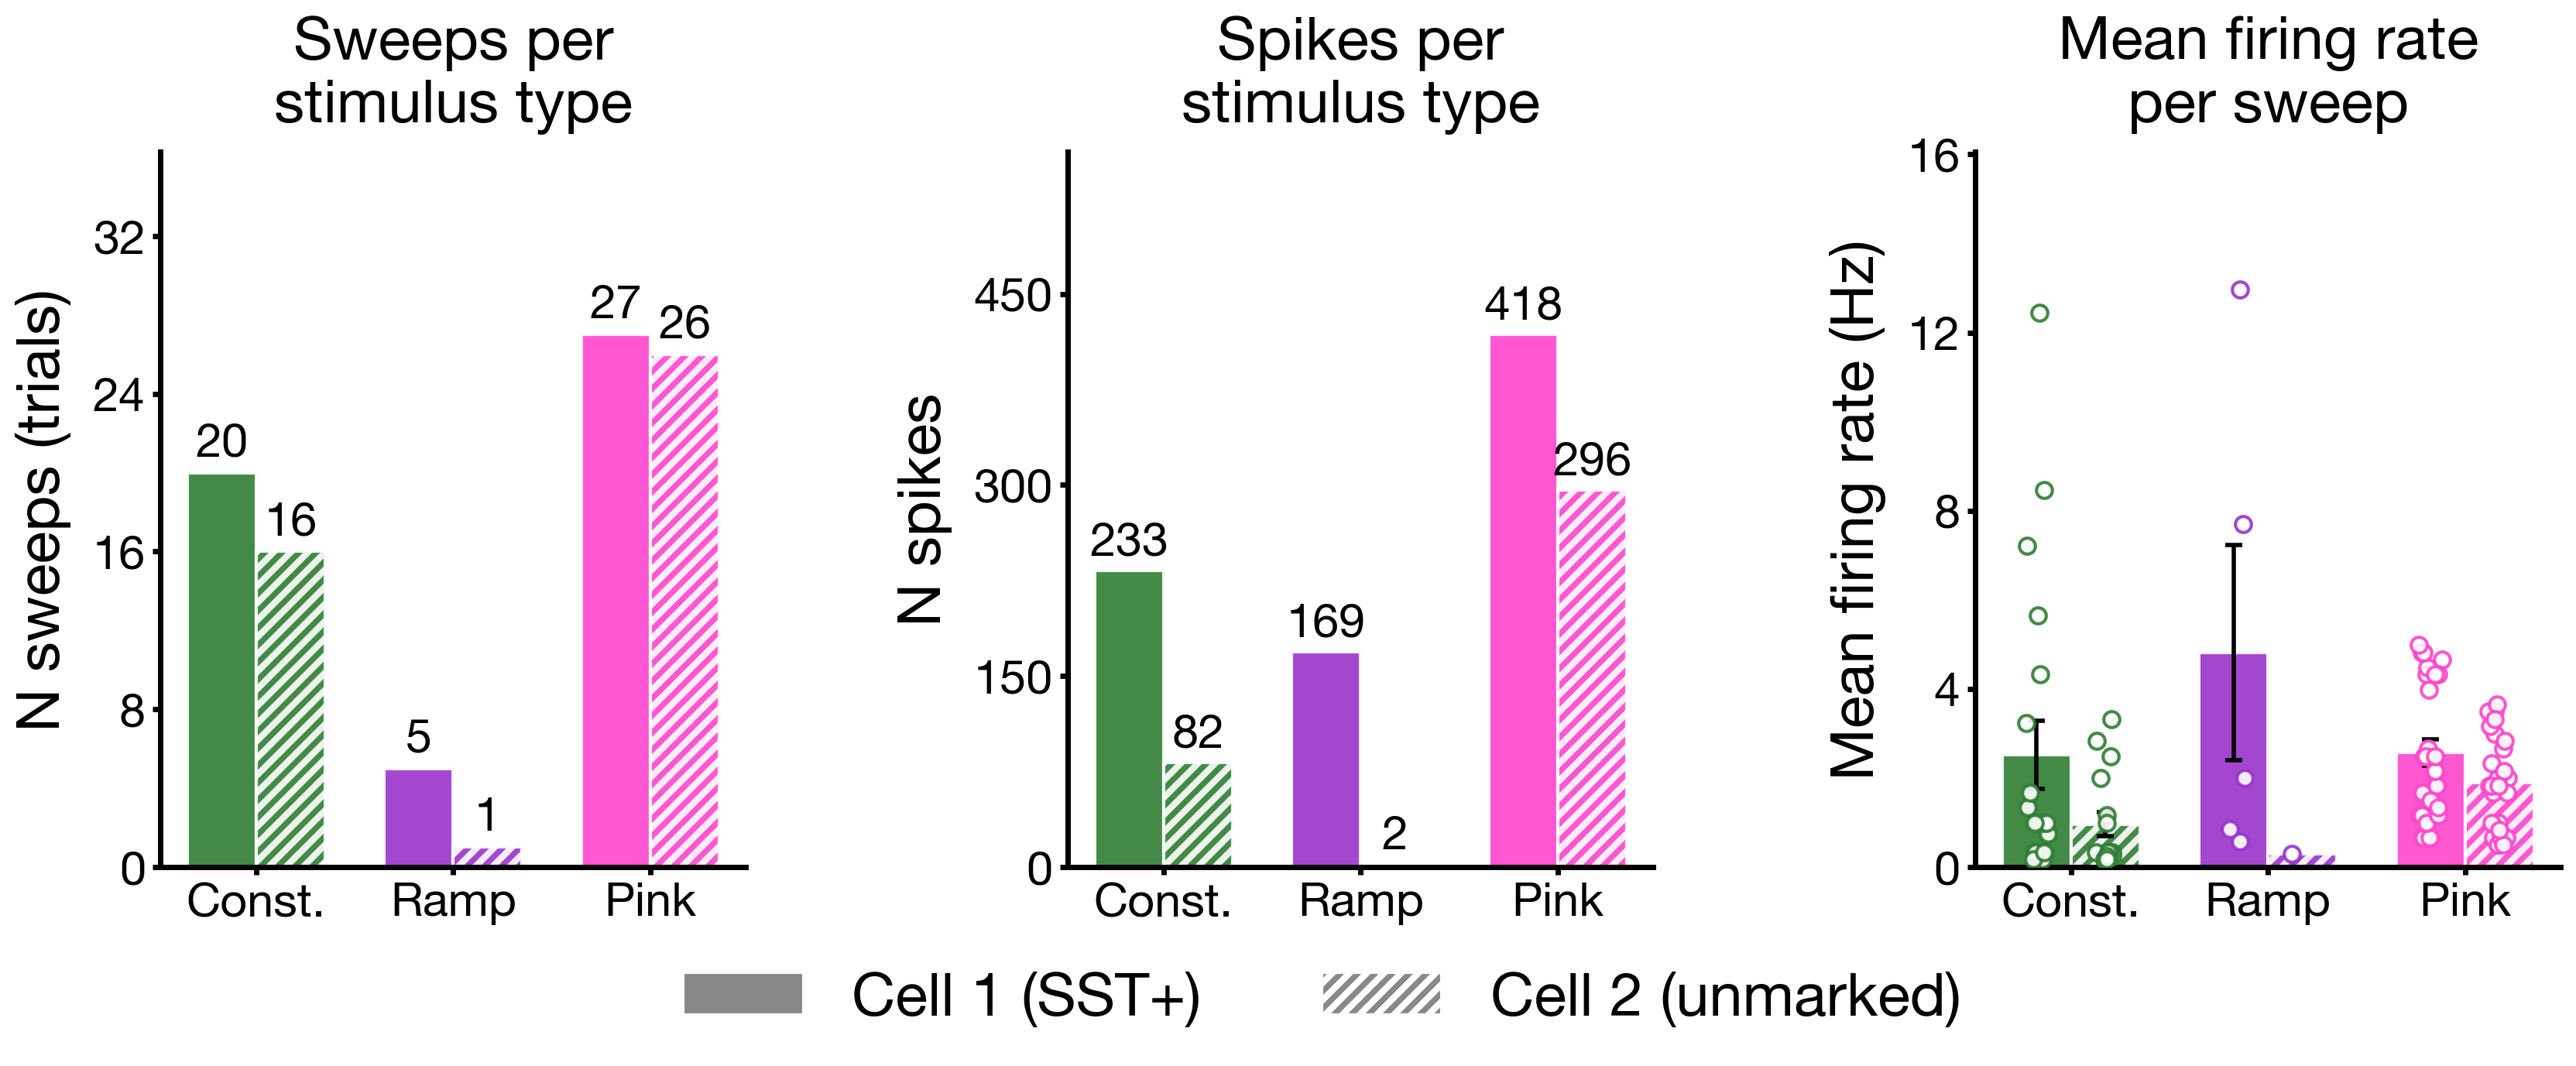

Saved.


In [4]:
# ── Figure ─────────────────────────────────────────────────────────────────────
import matplotlib
matplotlib.rcParams['hatch.linewidth']   = 3.0
matplotlib.rcParams['font.family']       = 'sans-serif'
matplotlib.rcParams['font.sans-serif']   = ['Helvetica Neue', 'Helvetica', 'Arial']

_FS_AX   = 28
_FS_TK   = 22
_FS_ANNOT= 22
_FS_LEG  = 28
_LW_SP   = 2.5

CELL_HATCHES  = ['',   '///']
CELL_EDGECOLS = ['white', 'white']
CELL_ALPHAS   = [0.90,  0.90]

fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.55)

x     = np.arange(len(STIM_ORDER))
bar_w = 0.35
offsets = [-bar_w/2, bar_w/2]

def _style(ax, n_yticks=5):
    ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=n_yticks, integer=True))
    ax.tick_params(axis='both', labelsize=_FS_TK, width=_LW_SP)
    ax.set_xticks(np.arange(len(STIM_ORDER)))
    ax.set_xticklabels(['Const.', 'Ramp', 'Pink'], fontsize=_FS_TK, fontweight='bold')
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight('bold')
    for spine in ax.spines.values():
        spine.set_linewidth(_LW_SP)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── A. N sweeps per stim type ──────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0])
for ci, (cnum, hatch, ecol, alpha) in enumerate(zip([1,2], CELL_HATCHES, CELL_EDGECOLS, CELL_ALPHAS)):
    df = cells[cnum]['df']
    sweep_counts = df.groupby('stim_type')['sweep'].nunique()
    vals = [sweep_counts.get(s, 0) for s in STIM_ORDER]
    bars = ax_a.bar(x + offsets[ci], vals, bar_w,
                    color=[STIM_COLS[s] for s in STIM_ORDER],
                    hatch=hatch, edgecolor=ecol, linewidth=1.5, alpha=alpha)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax_a.text(bar.get_x() + bar.get_width()/2, v + 0.4,
                      str(v), ha='center', va='bottom',
                      fontsize=_FS_ANNOT, fontweight='bold')

ax_a.set_ylabel('N sweeps (trials)', fontsize=_FS_AX, fontweight='bold', labelpad=10)
ax_a.set_title('Sweeps per\nstimulus type', fontsize=_FS_AX, fontweight='bold', pad=14)
ax_a.set_ylim(0, ax_a.get_ylim()[1] * 1.28)
_style(ax_a)

# ── B. N spikes per stim type ──────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1])
for ci, (cnum, hatch, ecol, alpha) in enumerate(zip([1,2], CELL_HATCHES, CELL_EDGECOLS, CELL_ALPHAS)):
    df = cells[cnum]['df']
    spk_counts = df['stim_type'].value_counts()
    vals = [spk_counts.get(s, 0) for s in STIM_ORDER]
    bars = ax_b.bar(x + offsets[ci], vals, bar_w,
                    color=[STIM_COLS[s] for s in STIM_ORDER],
                    hatch=hatch, edgecolor=ecol, linewidth=1.5, alpha=alpha)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax_b.text(bar.get_x() + bar.get_width()/2, v + 5,
                      str(v), ha='center', va='bottom',
                      fontsize=_FS_ANNOT, fontweight='bold')

ax_b.set_ylabel('N spikes', fontsize=_FS_AX, fontweight='bold', labelpad=10)
ax_b.set_title('Spikes per\nstimulus type', fontsize=_FS_AX, fontweight='bold', pad=14)
ax_b.set_ylim(0, ax_b.get_ylim()[1] * 1.28)
_style(ax_b)

# ── C. Mean firing rate — mean ± SEM bars + individual points ────────────────
ax_c = fig.add_subplot(gs[2])
rng = np.random.default_rng(42)

for ci, (cnum, hatch, ecol, alpha) in enumerate(zip([1,2], CELL_HATCHES, CELL_EDGECOLS, CELL_ALPHAS)):
    ps = cells[cnum]['per_sweep']
    for si, stim in enumerate(STIM_ORDER):
        vals = ps[ps['stim_type'] == stim]['fr_hz'].values
        if len(vals) == 0:
            continue
        col = STIM_COLS[stim]
        pos = x[si] + offsets[ci]
        mn  = np.mean(vals)
        sem = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0

        ax_c.bar(pos, mn, bar_w,
                 color=col, hatch=hatch,
                 edgecolor=ecol, linewidth=1.5, alpha=alpha)
        if sem > 0:
            ax_c.errorbar(pos, mn, yerr=sem,
                          fmt='none', color='black', lw=2.0, capsize=4, capthick=2.0,
                          zorder=5)
        jitter = rng.uniform(-0.06, 0.06, len(vals))
        ax_c.scatter(pos + jitter, vals,
                     s=55, color='white', edgecolors=col,
                     linewidths=1.5, alpha=0.9, zorder=6)

ax_c.set_ylabel('Mean firing rate (Hz)', fontsize=_FS_AX, fontweight='bold', labelpad=10)
ax_c.set_title('Mean firing rate\nper sweep', fontsize=_FS_AX, fontweight='bold', pad=14)
ax_c.set_ylim(0, ax_c.get_ylim()[1] * 1.18)
_style(ax_c, n_yticks=5)

# ── Shared legend — grey solid vs grey hatched ─────────────────────────────────
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#888888', edgecolor='white', linewidth=1.5,
          label='Cell 1 (SST+)'),
    Patch(facecolor='#888888', hatch='///', edgecolor='white', linewidth=1.5,
          label='Cell 2 (unmarked)'),
]
fig.legend(handles=legend_els, loc='lower center',
           bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False,
           fontsize=_FS_LEG, prop={'size': _FS_LEG, 'weight': 'bold'})

plt.savefig('pvc6_dataset_summary.pdf', bbox_inches='tight', dpi=300)
plt.savefig('pvc6_dataset_summary.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved.')

## Pink Noise Details

In [ ]:
import matplotlib
import matplotlib.cm as cm
from scipy.stats import gaussian_kde
matplotlib.rcParams['hatch.linewidth'] = 3.0

_FS_AX    = 28
_FS_TK    = 22
_LW_SP    = 2.5
_PINK     = '#FF44CC'

WINDOWS_MS  = [5, 25, 50, 100, 200, 300, 400, 500]
STAT_COLS   = ['stim_mean', 'stim_std', 'stim_exp']
STAT_LABS   = ['Stim mean (pA)', 'Stim std (pA)', 'Stim exponent']
STAT_TITL   = ['Pre-spike stim\nmean (pA)', 'Pre-spike stim\nstd (pA)', 'Pre-spike stim\nexponent']

# Color palette: light→dark by window length
_cmap   = cm.get_cmap('Blues', len(WINDOWS_MS) + 2)
WIN_COLS = {w: _cmap(i + 2) for i, w in enumerate(WINDOWS_MS)}

def _style_pn(ax, n_yticks=5, n_xticks=4):
    ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=n_yticks))
    if n_xticks:
        ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=n_xticks))
    ax.tick_params(axis='both', labelsize=_FS_TK, width=_LW_SP)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
    for spine in ax.spines.values():
        spine.set_linewidth(_LW_SP)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Load stim_extra for all windows for both cells
stim_vals = {}  # stim_vals[(cnum, wms, stat)] = array of values
for wms in WINDOWS_MS:
    col = f'stim_exp_{wms}ms' if wms != 5 else 'stim_exp_5ms'
    for cnum, suffix in [(1, ''), (2, '_c2')]:
        pkl = os.path.join(PICKLE_DIR, f'_stim_extra_{wms}ms{suffix}.pkl')
        if wms == 5:
            # use original df for 5ms
            df_pink = cells[cnum]['df'][cells[cnum]['df']['stim_type'] == 'pink']
            for stat in STAT_COLS:
                stim_vals[(cnum, wms, stat)] = df_pink[stat].dropna().values
        else:
            try:
                with open(pkl, 'rb') as fh:
                    se = pickle.load(fh)
                for stat in STAT_COLS:
                    key = f'{stat}_{wms}ms'
                    stim_vals[(cnum, wms, stat)] = se[key].dropna().values if key in se.columns else np.array([])
            except FileNotFoundError:
                for stat in STAT_COLS:
                    stim_vals[(cnum, wms, stat)] = np.array([])

fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.55)

for ci, (stat, lab, title) in enumerate(zip(STAT_COLS, STAT_LABS, STAT_TITL)):
    ax = fig.add_subplot(gs[ci])
    ax.set_title(title, fontsize=_FS_AX, fontweight='bold', pad=14)

    for wms in WINDOWS_MS:
        col = WIN_COLS[wms]
        for cnum, ls in [(1, '-'), (2, '--')]:
            vals = stim_vals.get((cnum, wms, stat), np.array([]))
            if len(vals) < 5:
                continue
            kde = gaussian_kde(vals, bw_method='silverman')
            x_grid = np.linspace(vals.min(), vals.max(), 300)
            ax.plot(x_grid, kde(x_grid), color=col, lw=2.0, ls=ls, alpha=0.85)

    ax.set_xlabel(lab, fontsize=_FS_AX, fontweight='bold')
    ax.set_ylabel('Density' if ci == 0 else '', fontsize=_FS_AX, fontweight='bold', labelpad=10)
    _style_pn(ax)

# Legend: windows (color) + cell (linestyle)
from matplotlib.lines import Line2D
_win_handles = [Line2D([0], [0], color=WIN_COLS[w], lw=2.5, label=f'{w} ms') for w in WINDOWS_MS]
_cell_handles = [
    Line2D([0], [0], color='black', lw=2.5, ls='-',  label='Cell 1 (SST+)'),
    Line2D([0], [0], color='black', lw=2.5, ls='--', label='Cell 2 (unmarked)'),
]
plt.subplots_adjust(bottom=0.30)
fig.legend(handles=_win_handles + _cell_handles,
           loc='lower center', bbox_to_anchor=(0.5, 0.0),
           ncol=5, frameon=False,
           fontsize=18, prop={'size': 18, 'weight': 'bold'})

plt.savefig('pvc6_pink_noise_details.pdf', bbox_inches='tight', dpi=300)
plt.savefig('pvc6_pink_noise_details.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved.')